# **PART I: Build, Train, and Test an LSTM with Time Series Data**

In [334]:
# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
%matplotlib inline


In [335]:
import tensorflow as tf
print(tf.__version__)

2.17.0


In [336]:
# For timeseries RNN LSTM NN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [337]:
# Importing Keras : TimeseriesGenerator
# Produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

#Import Keras: MinMaxScaler
# Used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

## Dataset : TSLA (Tesla Stock: 2022 - 2024)

In [338]:
dir_path_dataset_1= 'TSLA_HistoricalData_2022_2024_V5.csv'

## **Loading Dataset**

In [339]:

df = pd.read_csv(dir_path_dataset_1)

In [340]:
df.replace({'\$': ''}, regex=True, inplace=True)

df[['Close', 'Open', 'High', 'Low']] = df[['Close', 'Open', 'High', 'Low']].astype(float)

In [341]:
# Standardize the Date column
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Sort
df.sort_values(by="Date", inplace=True)

In [342]:
# reset the indexx after sorting
df.reset_index(drop=True, inplace=True)

In [343]:
# Keep only the first 503 rows
df = df.iloc[:503]

# Check the updated dataframe size
print(len(df))

503


In [344]:
df.head()

,Date,Close,Volume,Open,High,Low
0,2022-01-03,399.9266,104686060,382.5833,400.3566,378.6800
1,2022-01-04,383.1966,100248280,396.5166,402.6666,374.3500
2,2022-01-05,362.7066,80119808,382.2166,390.1133,360.3367
3,2022-01-06,354.9000,90336489,359.0000,362.6666,340.1666
4,2022-01-07,342.3200,84164768,360.1233,360.3099,336.6666


## EDA

In [345]:
df.shape

(503, 6)

In [346]:
df.dtypes

Date      datetime64[ns]
Close            float64
Volume             int64
Open             float64
High             float64
Low              float64
dtype: object

In [347]:
#Statistical Summary
df.describe()

,Date,Close,Volume,Open,High,Low
count,503,503.000000,5.030000e+02,503.000000,503.000000,503.000000
mean,2023-01-02 02:37:27.316103424,240.342014,1.121174e+08,240.679142,246.157742,234.657278
min,2022-01-03 00:00:00,108.100000,4.186474e+07,103.000000,111.750000,101.810000
25%,2022-07-05 12:00:00,197.475000,8.207969e+07,198.235000,202.900000,193.480000
50%,2023-01-03 00:00:00,241.866600,1.046861e+08,242.740000,247.140000,236.976600
75%,2023-07-05 12:00:00,276.025000,1.355520e+08,277.796650,283.315000,270.656650
max,2024-01-03 00:00:00,399.926600,3.065906e+08,396.516600,402.666600,378.680000
std,NaN,55.276085,4.126551e+07,55.733206,56.749472,54.231924


## **Keeping Only "Close" (for Closing Price) and Filter Out other fields**
Note: this project focuses only on the closing price

In [348]:
# df = df_ALL.iloc[:,4:5]
df = df[['Close']]

In [349]:
df.head()

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200


<Axes: >

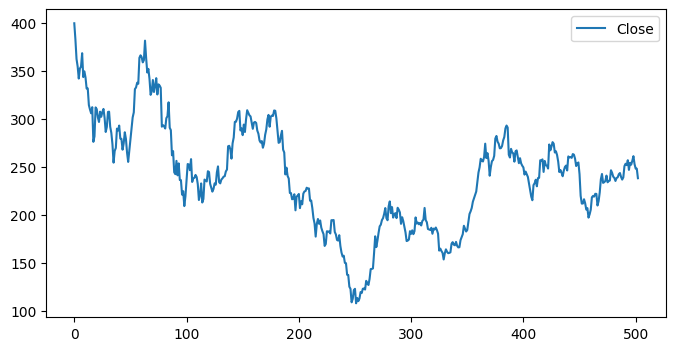

In [350]:
df.plot(figsize=(8,4))

## **Length of Input Time Series - Number of Input Time Steps**

In [351]:
# Setting the length of the input sequence
# i.e., the number of time series steps that are used to predict the future one
# Currently using 60 historical data points to predict the next one
# It means 60 consecutive closing prices will be used to predict the next one
length60 = 60

In [352]:
length60

60

## **Time Series Dataset: Train/test Split**

In [353]:
len(df)

503

In [354]:
# Split the DataFrame into training, validation, and test sets
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = len(df) - train_size - val_size

In [355]:
# Set percentage of data used for testing

test_percent = 0.1

In [356]:
# Number of data points reserved for testing the model 
# 10% of the original dataset

len(df)*test_percent

50.300000000000004

## **Splitting Data into Train/Test**

In [357]:
# We need to find the length of the testing dataset (We have already done so above (about 50 data points for testing)

test_length = np.round(len(df)*test_percent)
test_length

50.0

In [358]:
# Testing data starts at this index

# test_start_index = int(len(df) - test_length)
split_index = int(len(df) - test_length)
split_index

453

In [359]:
# Creating seperate training/ testing datasets

# Training dataset : All the indices from start to split_index (excluding split_index)
data_train = df.iloc[: split_index]

#Testing dataset : All indices from split_index - length60 to the end of the dataframe
#split_index - length60 : Need the last 60 historical data points (belong to data_train) to predict the first data point of the data_test
data_test = df.iloc[split_index - length60 :]

In [360]:
data_train.head(5)

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200


In [361]:
data_train.tail()

,Close
448,253.92
449,254.85
450,242.68
451,220.11
452,211.99


In [362]:
data_test.head(5)

,Close
393,266.44
394,267.43
395,261.07
396,254.11
397,259.32


In [363]:
data_test.tail()

,Close
498,261.44
499,253.18
500,248.48
501,248.42
502,238.45


## **Normalizing the Data (Scale into range [0,1]**

In [364]:
#Creating a MnMaxScaler to normalize the data
scaler = MinMaxScaler()

In [365]:
#Converting the data to floats
# ONLY scaling the training data- not the testing data

# Training the scaler to perform the normalization
scaler.fit(data_train)

MinMaxScaler()

In [366]:
#Normalizing the training dataset
normalized_train = scaler.transform(data_train)

#Normalizing the testing dataset
normalized_test = scaler.transform(data_test)

## Creating TimeseriesGenerator for Training

In [367]:
#TimeseriesGenerator : Generating time series batches for training/testing

#Set the length of the input sequence as length60 (like above)
#batch_size : Number of time series samples in each batch
#Sample: A single time series input that has 60 historical data points
batch_size32 = 32

# Creating a TimeseriesGeneerator for training: train_tsGenerator
# to produce time series batches used to train the model
# TimeseriesGenerator (inputs, outputs, length, batch_size)
train_tsGenerator60 = TimeseriesGenerator(normalized_train, normalized_train, length=length60, batch_size=batch_size32)

In [368]:
len(normalized_train)

453

In [369]:
len(train_tsGenerator60)

13

In [370]:
# What does the first batch look like?
X,y = train_tsGenerator60[0]

In [371]:
print(X)

[[[1.        ]
  [0.94267144]
  [0.87245851]
  ...
  [0.78395869]
  [0.87670761]
  [0.88553716]]

 [[0.94267144]
  [0.87245851]
  [0.84570769]
  ...
  [0.87670761]
  [0.88553716]
  [0.87916352]]

 [[0.87245851]
  [0.84570769]
  [0.8025999 ]
  ...
  [0.88553716]
  [0.87916352]
  [0.86044247]]

 ...

 [[0.6298946 ]
  [0.68320229]
  [0.68429883]
  ...
  [0.61834665]
  [0.52863584]
  [0.54340488]]

 [[0.68320229]
  [0.68429883]
  [0.63056829]
  ...
  [0.52863584]
  [0.54340488]
  [0.46797173]]

 [[0.68429883]
  [0.63056829]
  [0.60844351]
  ...
  [0.54340488]
  [0.46797173]
  [0.46111835]]]


In [372]:
print(y)

[[0.87916352]
 [0.86044247]
 [0.86842666]
 [0.9379426 ]
 [0.87604523]
 [0.82407361]
 [0.83720949]
 [0.80092082]
 [0.74431186]
 [0.75689913]
 [0.79735706]
 [0.75467178]
 [0.77670541]
 [0.80395893]
 [0.74576238]
 [0.78183414]
 [0.77757339]
 [0.76954363]
 [0.63064847]
 [0.6364622 ]
 [0.63189339]
 [0.62418333]
 [0.66094044]
 [0.6681478 ]
 [0.71768646]
 [0.62706176]
 [0.61834665]
 [0.52863584]
 [0.54340488]
 [0.46797173]
 [0.46111835]
 [0.50862396]]


# **Build, Train and Test Model**

## Building LSTM Model

In [373]:
#Setting number of features
#Feature: Attribute/Variable of the dataset - used as predictors

#Only using one feature: Close price
n_features = 1

In [374]:
# Defining the model
model = Sequential()

# Adding on LSTM layer
# This layer has 50 LSTM cells
# Activation function: ReLU
# return_sequences = True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(length60, n_features)))

#Dropout layer 1
model.add(Dropout(0.2))

# Adding the 2nd LSTM layer
# return_sequences=True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(units=50, activation='relu', return_sequences=True))

#Dropout layer 2
model.add(Dropout(0.2))

#Adding the 4th LSTM layer
model.add(LSTM(units=60, activation='relu'))

#Adding a FC layer for the final prediction
model.add(Dense(1))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## **Compiling the model**

In [375]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

model.summary()
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 60)             │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,301 (223.83 KB)

 Trainable params: 57,301 (223.83 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## **Training (Fit) Model using fit_generator()**

In [376]:
# Training the model
# fit_generator is depricated for this version of tensorflow, so I ave used model.fit()
model.fit(train_tsGenerator60, epochs=100)

Epoch 1/100
 2/13 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1138

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.1368
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0189
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0237
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0130
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0195
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0138
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0119
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0127
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0166
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0140
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0120
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0090
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0099
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0076
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0089
E

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0031
Epoch 82/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0039
Epoch 83/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0027
Epoch 84/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0026
Epoch 85/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0029
Epoch 86/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0021
Epoch 87/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0025
Epoch 88/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0021
Epoch 89/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0026
Epoch 90/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0034
Epoch 91/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0024
Epoch 92/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0022
Epoch 93/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0021
Epoch 94/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0028
Epoch 95/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 

## **Visualizing the model's performance after Training**

In [377]:
loss_history_keys = model.history.history.keys()

#model.history.history is a dict
# 'loss' : its key
# 'loss' : loss during training
loss_history_keys

dict_keys(['loss'])

<Axes: >

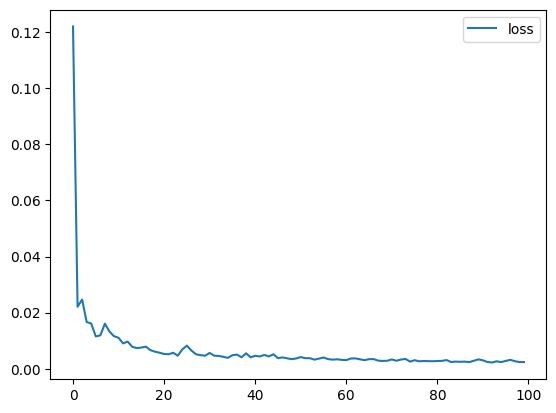

In [378]:
#Load the loss data (model.history.history) into a data frame
df_model_loss = pd.DataFrame(model.history.history)

#Visualize the loss data using DataFrame.plot()
df_model_loss.plot()

# **Prediction for Testing: Using TimeseriesGenerator**

## **Create TimeseriesGenerator for Testing**

In [379]:
# batch_size must be 1
batch_size1 = 1

# Create a TimeSeriesGenerator for testing: test_tsGenerator
test_tsGenerator60 = TimeseriesGenerator(normalized_test, normalized_test, length=length60, batch_size=batch_size1)

## **Predicting Future Data Points for Testing**

In [380]:
#model.predict_generator does not work with the latest version of tensorflow, so we use model.predict
normalized_prediction = model.predict(test_tsGenerator60)

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [381]:
#Prediction is a numpy 2D array with only one column

normalized_prediction

array([[0.4216121 ],
       [0.39592975],
       [0.37627402],
       [0.3630201 ],
       [0.35351872],
       [0.34763113],
       [0.34089223],
       [0.33447188],
       [0.3305778 ],
       [0.33362746],
       [0.3422646 ],
       [0.35295796],
       [0.36366645],
       [0.37226745],
       [0.37282497],
       [0.36812916],
       [0.36484435],
       [0.36980143],
       [0.3827956 ],
       [0.39664558],
       [0.40830094],
       [0.41695097],
       [0.4247075 ],
       [0.4287661 ],
       [0.43001443],
       [0.42982215],
       [0.43369025],
       [0.43992013],
       [0.4450393 ],
       [0.44760957],
       [0.44658372],
       [0.44456849],
       [0.44302782],
       [0.44372126],
       [0.44662508],
       [0.4487982 ],
       [0.44841647],
       [0.44695386],
       [0.4501602 ],
       [0.4580201 ],
       [0.46708155],
       [0.47703934],
       [0.48162532],
       [0.48391134],
       [0.4838788 ],
       [0.48420334],
       [0.48734185],
       [0.488

In [382]:
len(normalized_prediction)

50

In [383]:
# Converting normalized predictions back to the true values
prediction = scaler.inverse_transform(normalized_prediction)

In [384]:
print(len(prediction))

50


In [385]:
# Flattening all the 2D array

# data_train = data_train.reshape((-1))
# data_test = data_test.reshape((-1))
# prediction = prediction.reshape((-1))

prediction_index = np.arange(393, 393 + len(prediction), step=1)

#prediction_index = np.arange(599, 599 + len(prediction), step=1)

df_prediction = pd.DataFrame(data=prediction,index=prediction_index, columns=['Prediction'])



In [386]:
df_prediction

,Prediction
393,231.137619
394,223.642838
395,217.906769
396,214.038910
397,211.266174
398,209.548004
399,207.581421
400,205.707794
401,204.571396
402,205.461365


## **Visualizing the Prediction**

<Axes: >

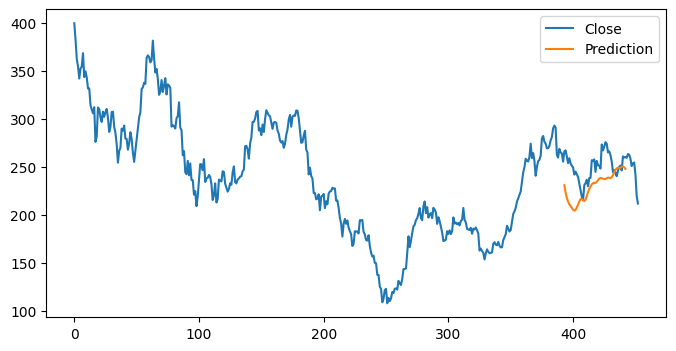

In [387]:
ax = data_train.plot()
df_prediction.plot(ax=ax, figsize=(8, 4))

# **Time Series Forecasting with LSTM**

## **Preprocess Full Input Dataset**

In [388]:
# Still using MinMaxScaler to normalize the full input dataset df

full_scaler = MinMaxScaler()
normalized_full_data = full_scaler.fit_transform(df)

## **Creating a TimeseriesGenerator for Forecasting**

In [389]:
# Number of time steps of the input time series
# Still use length60
length60

60

In [390]:
# Creating a timeseries Generator for forcasting
forecast_tsGenerator = TimeseriesGenerator(normalized_full_data, normalized_full_data, length=length60, batch_size=batch_size32)

# Fit LSTM model for Forecasting

In [391]:
# Train/Fit LSTM model
# We do not validate, we only FORECAST

model.fit(forecast_tsGenerator, epochs= 100)

Epoch 1/100
 3/14 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0012

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0020
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0024
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0022
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0025
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0023
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0026
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0026
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0023
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0023
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0024
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0021
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0025
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0027
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0022
Epoch 15/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0031
E

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0020
Epoch 82/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0021
Epoch 83/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0016
Epoch 84/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0022
Epoch 85/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0018
Epoch 86/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0016
Epoch 87/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0018
Epoch 88/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0019
Epoch 89/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0014
Epoch 90/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0019
Epoch 91/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0018
Epoch 92/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0023
Epoch 93/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0018
Epoch 94/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0015
Epoch 95/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 

## **Forecast Using the LSTM NN**

In [392]:
forecast = []

# Set periods with time span of forecasting
# Lets forecast for the next 107 business days 
periods = 107

first_eval_batch = normalized_full_data[-length60:]
current_batch = first_eval_batch.reshape((1, length60, n_features))

for i in range(periods):
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    forecast.append(current_pred)
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

## **Inverse to Tansform Normalized Data Back into True Values**

In [393]:
# Convert normalized predictions back to the original scale
forecast = full_scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

forecast

array([250.69402, 250.69301, 252.95178, 256.167  , 259.63846, 263.02216,
       266.43762, 269.85822, 273.2036 , 276.36252, 279.26355, 281.86765,
       284.15567, 286.12195, 287.77032, 289.11   , 290.15466, 290.921  ,
       291.42715, 291.69238, 291.7345 , 291.50253, 291.06174, 290.46967,
       289.75974, 288.96152, 288.1023 , 287.20538, 286.2895 , 285.36923,
       284.45532, 283.55515, 282.67444, 281.81796, 280.9898 , 280.19382,
       279.43518, 278.71997, 278.05463, 277.4442 , 276.8941 , 276.41058,
       275.99954, 275.66406, 275.40695, 275.22885, 275.12912, 275.1059 ,
       275.15594, 275.27478, 275.45795, 275.6995 , 275.99298, 276.33194,
       276.7073 , 277.11044, 277.5349 , 277.97336, 278.41953, 278.86697,
       279.30948, 279.7423 , 280.15967, 280.55756, 280.93207, 281.27972,
       281.59778, 281.8835 , 282.13495, 282.3506 , 282.52936, 282.67072,
       282.7743 , 282.8405 , 282.8702 , 282.86465, 282.82547, 282.7548 ,
       282.6551 , 282.52905, 282.3797 , 282.21024, 

In [394]:
df

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200
...,...
498,261.4400
499,253.1800
500,248.4800
501,248.4200


## **Creating a new timestamp index with pandas**

In [395]:
# Calculate forecast index
# Set forecast index starting immediately after the last index of historical data
last_index = df.index[-1]  # Get the last index from the historical dataset
forecast_index = range(last_index + 1, last_index + 1 + len(forecast))  # Generate aligned indices


In [396]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index, columns=['Forecast'])

In [397]:
forecast_df

,Forecast
503,250.694016
504,250.693008
505,252.951782
506,256.166992
507,259.638458
...,...
605,279.155121
606,279.171387
607,279.202942
608,279.248535


# **Plotting the forecast**

<Axes: >

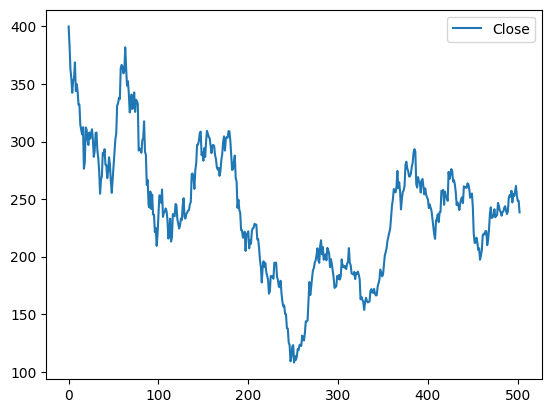

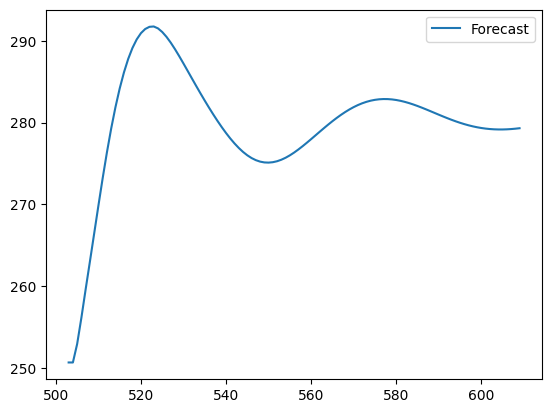

In [398]:
df.plot()
forecast_df.plot()

## **Joining Pandas Plots**

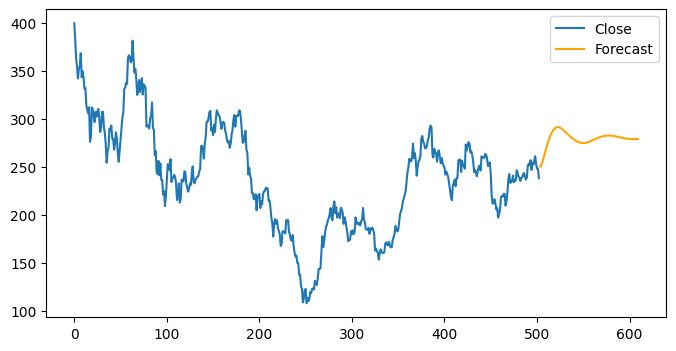

In [399]:
# Create DataFrame for the forecast
forecast_df = pd.DataFrame({'Forecast': forecast}, index=forecast_index)

# Plot historical and forecast data
ax = df['Close'].plot(figsize=(8, 4), label='Close')  # Historical data
forecast_df.plot(ax=ax, label='Forecast', color='orange')  # Forecasted data
plt.legend()
plt.show()

         Date      Close    Volume       Open       High        Low
0  02-01-2022  $310.4166  73138357  $311.7366  $314.5666  $301.6666
1  03-01-2022  $288.1233  74766877  $289.8933  $296.6266  $284.5933
2  04-01-2022    $361.53  54263225  $360.3833  $364.9166  $355.5466
3  06-01-2022    $246.79  77247968    $251.72  $257.3266    $243.64
4  07-01-2022  $227.2633  74460457    $227.00    $230.23    $222.12


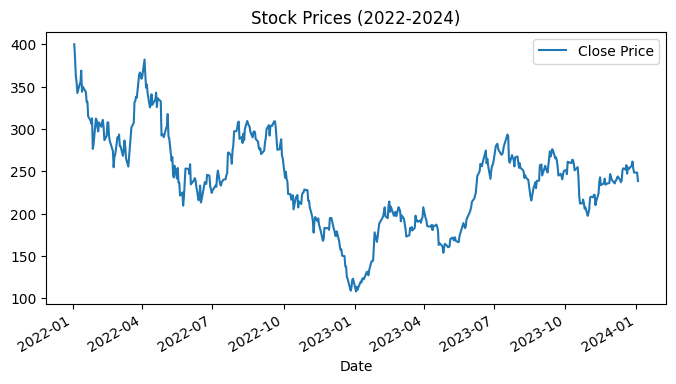

In [400]:
dir_path_dataset = 'TSLA_HistoricalData_2022_2024_V5.csv'
df = pd.read_csv(dir_path_dataset)

# Inspecting the dataset
print(df.head())

df.replace({'\$': ''}, regex=True, inplace=True)

df[['Close', 'Open', 'High', 'Low']] = df[['Close', 'Open', 'High', 'Low']].astype(float)

# Standardize the Date column
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Sort
df.sort_values(by="Date", inplace=True)

# reset the indexx after sorting
df.reset_index(drop=True, inplace=True)

# Keep only the first 503 rows
df = df.iloc[:503]

# Check the updated dataframe size
#print(len(df))

# Filtering relevant columns (only 'Date' and 'Close')
df = df.loc[:, ['Date', 'Close']]

# Converting 'Date' to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Filtering data for specific time period (if required)
#start_date = '2022-04-26'  # Adjust to your dataset's date range
#end_date = '2024-04-25'
#df_filtered = df.loc[start_date:end_date]

df_filtered=df

# Plotting the filtered data
df_filtered['Close'].plot(figsize=(8,4), title='Stock Prices (2022-2024)', label='Close Price')
plt.legend()
plt.show()


In [401]:
forecast_df['Forecast'].values

array([250.69402, 250.69301, 252.95178, 256.167  , 259.63846, 263.02216,
       266.43762, 269.85822, 273.2036 , 276.36252, 279.26355, 281.86765,
       284.15567, 286.12195, 287.77032, 289.11   , 290.15466, 290.921  ,
       291.42715, 291.69238, 291.7345 , 291.50253, 291.06174, 290.46967,
       289.75974, 288.96152, 288.1023 , 287.20538, 286.2895 , 285.36923,
       284.45532, 283.55515, 282.67444, 281.81796, 280.9898 , 280.19382,
       279.43518, 278.71997, 278.05463, 277.4442 , 276.8941 , 276.41058,
       275.99954, 275.66406, 275.40695, 275.22885, 275.12912, 275.1059 ,
       275.15594, 275.27478, 275.45795, 275.6995 , 275.99298, 276.33194,
       276.7073 , 277.11044, 277.5349 , 277.97336, 278.41953, 278.86697,
       279.30948, 279.7423 , 280.15967, 280.55756, 280.93207, 281.27972,
       281.59778, 281.8835 , 282.13495, 282.3506 , 282.52936, 282.67072,
       282.7743 , 282.8405 , 282.8702 , 282.86465, 282.82547, 282.7548 ,
       282.6551 , 282.52905, 282.3797 , 282.21024, 

In [402]:
forecast_df['Forecast']

503    250.694016
504    250.693008
505    252.951782
506    256.166992
507    259.638458
          ...    
605    279.155121
606    279.171387
607    279.202942
608    279.248535
609    279.306885
Name: Forecast, Length: 107, dtype: float32

            Close    Forecast
2024-05-27    NaN  279.155121
2024-05-28    NaN  279.171387
2024-05-29    NaN  279.202942
2024-05-30    NaN  279.248535
2024-05-31    NaN  279.306885


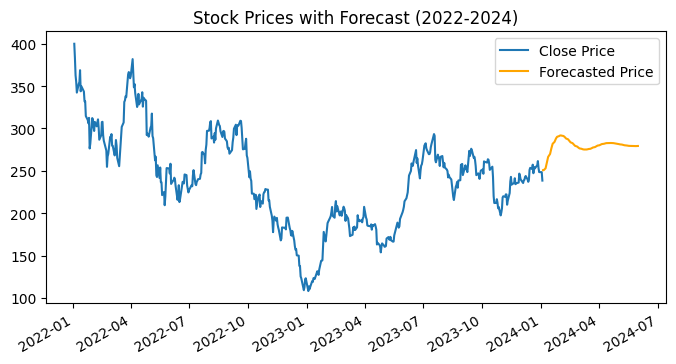

In [403]:
# Extending df_filtered to include forecasted dates
future_dates = pd.date_range(start=df_filtered.index[-1] + pd.Timedelta(days=1), periods=len(forecast), freq='B')
df_extended = df_filtered.reindex(df_filtered.index.union(future_dates))

# Adding the Forecast column
df_extended['Forecast'] = None  # Initialize a blank Forecast column
df_extended.loc[future_dates, 'Forecast'] = forecast  # Adding forecasted values to the new dates

# Inspect the result
print(df_extended.tail())

# Plot the data
ax = df_extended['Close'].plot(figsize=(8,4), label='Close Price')  # Historical prices
df_extended['Forecast'].plot(ax=ax, label='Forecasted Price', color='orange')  # Forecasted values
plt.legend()
plt.title("Stock Prices with Forecast (2022-2024)")
plt.show()
